In [103]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [85]:
path=r"/Users/igorbykov/Desktop/Spring I Courseworks/ADT due 29-03-26/data.csv" 
data=pd.read_csv(path)
data

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7
0,1,32400.000000,99.98,99.980000,99.980000,5,5,0
1,1,32406.147188,100.00,99.980000,99.980000,7,3,0
2,1,32409.115557,100.02,100.004000,99.996000,4,6,1
3,1,32471.025717,100.04,100.021333,100.018667,6,4,1
4,1,32473.743952,100.02,100.042000,100.038000,8,2,1
...,...,...,...,...,...,...,...,...
102192,100,62630.991830,91.30,91.320000,91.320000,3,7,0
102193,100,62636.683584,91.28,91.300000,91.300000,3,7,1
102194,100,62725.025716,91.30,91.280000,91.280000,5,5,1
102195,100,62822.717694,91.28,91.300000,91.300000,4,6,0


In [86]:
# (1) Day dof the trade; 
# (2) Time tof the trade, in seconds after midnight; 
# (3) Fundamental value vd,t of the stock immediately after the trade; 
# (4) Ask price Ad,t; 
# (5) Bid price Bd,t; 
# (6) Number of buy orders Buysd,t; 
# (7) Number of sell orders Sellsd,t; 
# (8) Signal given by the data provider sd,t.

new = 'day sec_post_midnight fund_post_trade ask bid n_buy_orders n_sell_orders signal'.split(' ')
old = list(data.columns)
data=data.rename({old[i]:col for i, col in enumerate(new)}, axis=1)
data.index.names = ['trade']
data

,day,sec_post_midnight,fund_post_trade,ask,bid,n_buy_orders,n_sell_orders,signal
trade,,,,,,,,
0,1,32400.000000,99.98,99.980000,99.980000,5,5,0
1,1,32406.147188,100.00,99.980000,99.980000,7,3,0
2,1,32409.115557,100.02,100.004000,99.996000,4,6,1
3,1,32471.025717,100.04,100.021333,100.018667,6,4,1
4,1,32473.743952,100.02,100.042000,100.038000,8,2,1
...,...,...,...,...,...,...,...,...
102192,100,62630.991830,91.30,91.320000,91.320000,3,7,0
102193,100,62636.683584,91.28,91.300000,91.300000,3,7,1
102194,100,62725.025716,91.30,91.280000,91.280000,5,5,1


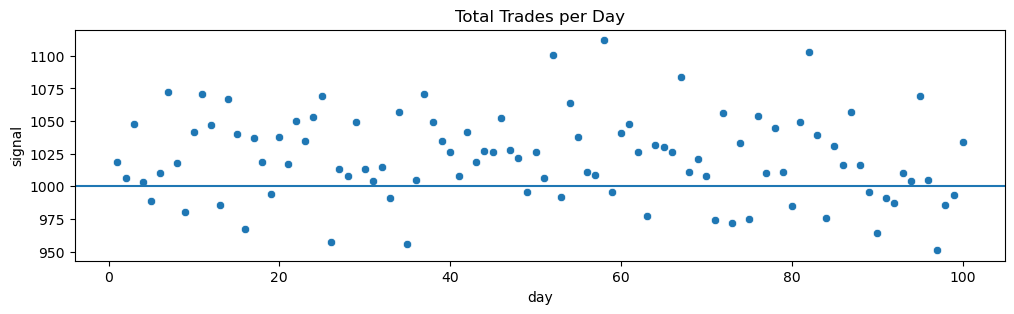

In [87]:
plt.figure(figsize=(12,3))
plt.title('Total Trades per Day')
sns.scatterplot(data.groupby('day').count()['signal'])
plt.axhline(1000)
plt.show()

In [88]:
data['fund_post_trade']

trade
0          99.98
1         100.00
2         100.02
3         100.04
4         100.02
           ...  
102192     91.30
102193     91.28
102194     91.30
102195     91.28
102196     91.30
Name: fund_post_trade, Length: 102197, dtype: float64

In [89]:
data['delta_fund_post_trade'] = data['fund_post_trade'] - data['fund_post_trade'].shift(1)
data['fund_post_trade_prev']=data['fund_post_trade'].shift(1)
data=data.dropna()
data

,day,sec_post_midnight,fund_post_trade,ask,bid,n_buy_orders,n_sell_orders,signal,delta_fund_post_trade,fund_post_trade_prev
trade,,,,,,,,,,
1,1,32406.147188,100.00,99.980000,99.980000,7,3,0,0.02,99.98
2,1,32409.115557,100.02,100.004000,99.996000,4,6,1,0.02,100.00
3,1,32471.025717,100.04,100.021333,100.018667,6,4,1,0.02,100.02
4,1,32473.743952,100.02,100.042000,100.038000,8,2,1,-0.02,100.04
5,1,32487.492880,100.04,100.020000,100.020000,5,5,0,0.02,100.02
...,...,...,...,...,...,...,...,...,...,...
102192,100,62630.991830,91.30,91.320000,91.320000,3,7,0,-0.02,91.32
102193,100,62636.683584,91.28,91.300000,91.300000,3,7,1,-0.02,91.30
102194,100,62725.025716,91.30,91.280000,91.280000,5,5,1,0.02,91.28


In [100]:
def accuracy_indicator(row):
    if row['delta_fund_post_trade']>0 and row['signal']==1:
        return 1
    elif row['delta_fund_post_trade']<0 and row['signal']==0:
        return 1
    else:
        return 0
    
def fundamental_expecatation(row, tau, step):
    if row['signal']==1:
        return row['fund_post_trade_prev']+(2*tau-1)*step
    elif row['signal']==0:
        return row['fund_post_trade_prev']-(2*tau-1)*step
    
def trade_decision(row):
    if row['E[fund_post_trade]']>row['ask']:
        return 1
    elif row['E[fund_post_trade]']<row['bid']:
        return -1
    else:
        return 0
    
def exepcted_profit(row, order_size):
    if row['trade_decision']==-1:
        return order_size*(row['bid']-row['fund_post_trade'])
    if row['trade_decision']==1:
        return order_size*(row['fund_post_trade']-row['ask'])
    else:
        return 0

In [ ]:
data['signal_accurate']=data.apply(lambda row: accuracy_indicator(row), axis=1)
tau = data['signal_accurate'].sum()/len(data)

/var/folders/4_/ym5ph8gd12lfqnhrxz6p53rw0000gn/T/ipykernel_39690/1594099226.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['signal_accurate']=data.apply(lambda row: accuracy_indicator(row), axis=1)
/var/folders/4_/ym5ph8gd12lfqnhrxz6p53rw0000gn/T/ipykernel_39690/1594099226.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['E[fund_post_trade]']=data.apply(lambda row: fundamental_expecatation(row, tau=tau, step=0.02), axis=1)
/var/folders/4_/ym5ph8gd12lfqnhrxz6p53rw0000gn/T/ipykernel_39690/15

3396548.571748109


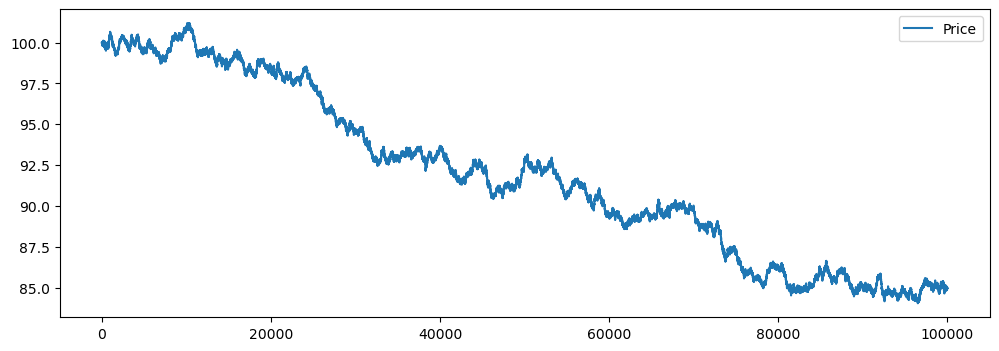

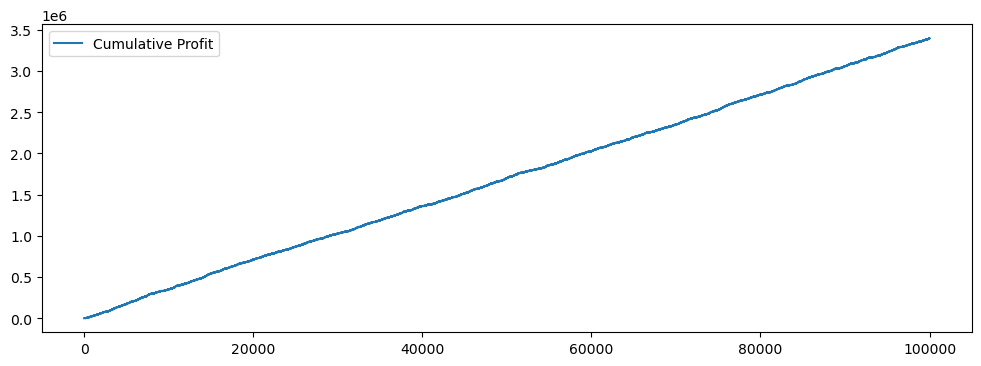

In [326]:
path = []
cum_profit=[]

D=100
T=1_000
step_size=0.02
tau=tau
N_informed=1
N_uninformed=9
min_order = 10_000
size=min_order
v_0 = 100
S_0 = 0 

profit = 0
v_prev = v_0

for d in range(D):

    # Each day, 
    S_upd=S_0
    cum_adverse_selection = 0

    for t in range(T):

        step = random.choice([-1,1])*step_size
        v_t = v_prev + step

        if step>0:
            s = random.choices([1,0], weights = [tau, 1-tau])[0]
        if step<0:
            s = random.choices([0,1], weights = [tau, 1-tau])[0]
        
        sells = np.random.binomial(N_uninformed,0.5)
        buys=N_uninformed-sells
        
        ask = v_prev + S_upd
        bid = v_prev - S_upd

        if S_upd<(2*tau-1)*step_size:
            if s==1:
                profit += (v_t - ask)*min_order
                buys += 1
            elif s==0:
                profit += (bid - v_t)*min_order
                sells += 1

        path.append(v_prev)
        cum_profit.append(profit)

        v_prev = v_t
        cum_adverse_selection += step * (sells - buys)
        S_upd = max(0, -0.1 * cum_adverse_selection / (t + 1))
    
print(profit)
plt.figure(figsize=(12,4))
plt.plot(path, label='Price')
plt.legend()

plt.figure(figsize=(12,4))
plt.plot(cum_profit, label='Cumulative Profit')
plt.legend()